# Retail Signals: where the autumn sales increase came from

I wanted to go beyond a monthly revenue chart: was the late-2011 increase driven by **more invoices**, **larger average invoices**, or both? Before calculating anything by month, I needed to fix the date representation. This notebook follows the reasoning and displays the actual outputs; the reusable functions live in `scripts/analyze.py`.

**Important:** I worked with a **filtered user-supplied 13-column extract** (384,721 positive-quantity/price rows with known customer IDs), not an unfiltered original workbook. The original CSV is deliberately not distributed with the GitHub-ready portfolio. The bundled `results/` tables let this notebook display the evidence without raw data.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
ROOT=Path.cwd()
if not (ROOT/'results').exists(): ROOT=Path.cwd().parent
sys.path.insert(0,str(ROOT/'scripts'))
from analyze import summary
R=ROOT/'results'
raw=ROOT/'data/raw/Online Retail.csv'
if raw.exists():
    metrics,_=summary(raw)
    print('Exact source found and analysis regenerated. SHA-256:',metrics['raw_sha256'])
else:
    metrics=json.loads((R/'verified_metrics.json').read_text())
    print('Using bundled VERIFIED summary outputs. For a raw refresh, see README. Source SHA-256:',metrics['raw_sha256'])
monthly=pd.read_csv(R/'monthly.csv')
segments=pd.read_csv(R/'segments.csv')
cohorts=pd.read_csv(R/'cohort_retention.csv')
print('Rows:',metrics['rows'],'invoices:',metrics['invoices'],'customers:',metrics['customers'])

Exact source found and analysis regenerated. SHA-256: a4b796f9bd7a07f3881429bcc64165d0d03578a1b9f03a800eb4baebb0737a9a
Rows: 384721 invoices: 17635 customers: 4261


## 1. The dates needed fixing first

I checked invoice 536365 and found `2010-01-12 08:26:00`, which is inconsistent with the invoice sequence for December 2010. The supplied file has day/month reversals *only where both date components permit the ambiguity*. I tested a systematic swap rather than manually changing selected dates. It repaired **147,998 rows** and brought the invoice-number chronology check from **21 inversions to zero**. The imported `Year`, `Month`, `Week`, `Day` and `DayOfWeek` fields were based on the incorrect version; the pipeline rebuilds the calendar.

I did not silently remove the **5,178 exact duplicate lines**. If two identical product lines were genuinely recorded on the same invoice, there is no separate line ID here to distinguish them. Instead, I kept them and measured the difference if removed.

In [2]:
checks={k:metrics[k] for k in ['date_swapped_rows','invoice_date_inversions_raw','invoice_date_inversions_corrected','invoices_with_multiple_corrected_timestamps','duplicate_exact_rows','duplicate_revenue_sensitivity']}
pd.Series(checks).to_frame('Verified result')

,Verified result
date_swapped_rows,147998.00
invoice_date_inversions_raw,21.00
invoice_date_inversions_corrected,0.00
invoices_with_multiple_corrected_timestamps,30.00
duplicate_exact_rows,5178.00
duplicate_revenue_sensitivity,23119.37


## 2. Decomposing the September-to-November movement

If revenue moves, it's tempting to attribute that to higher basket value. Invoice counts are the obvious first check. I compared **two complete months**, September and November 2011. I did not use December 2011 in a month-over-month comparison: the extract stops on December 9.

In [3]:
focus=monthly[monthly.Month.isin(['2011-09','2011-11'])][['Month','Revenue','Orders','AOV']].set_index('Month')
focus.loc['Change %']=100*(focus.loc['2011-11']/focus.loc['2011-09']-1)
focus.round(2)

,Revenue,Orders,AOV
Month,,,
2011-09,657406.00,1669.00,393.89
2011-11,881270.87,2553.00,345.19
Change %,34.05,52.97,-12.36


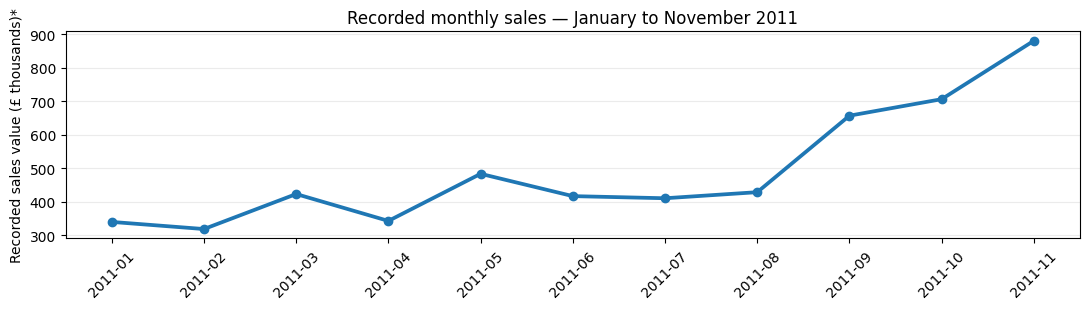

In [4]:
full=monthly[monthly.Month.between('2011-01','2011-11')]
fig,ax=plt.subplots(figsize=(11,3.2))
ax.plot(full.Month,full.Revenue/1000,marker='o',linewidth=2.7)
ax.set_title('Recorded monthly sales — January to November 2011')
ax.set_ylabel('Recorded sales value (£ thousands)*')
ax.tick_params(axis='x',rotation=45)
ax.grid(axis='y',alpha=.25)
plt.tight_layout();plt.show()

**The revised interpretation:** recorded sales rose **34.1%**, but invoices rose **53.0%** and average order value fell **12.4%**. The order-count increase dominates the arithmetic decomposition. This does **not** identify the causal reason: there are no marketing, discount, profitability or full-return variables in this extract.

## 3. Returning is not the same as retained

I first grouped customers by whether they placed at least two invoices *at any time in the observed file*. That's a useful description of where historical revenue came from, but it uses the whole observation window. It would be wrong to present that as the probability a newly observed customer returns.

So I added a different question: given the month a customer **first appears in this extract**, does that customer appear one, two or three months later? This is observed month-specific retention, not cumulative survival or verified first-ever acquisition.

In [5]:
print('Multi-invoice customers:',metrics['repeat_customers_multi_invoice'])
print('Share of observed revenue from retrospective multi-invoice group:',round(100*metrics['repeat_customers_multi_invoice_revenue']/metrics['revenue'],1),'%')
segments[['Segment','Customers','Revenue','RevenueSharePct']].sort_values('Revenue',ascending=False)

Multi-invoice customers: 2773
Share of observed revenue from retrospective multi-invoice group: 92.1 %


,Segment,Customers,Revenue,RevenueSharePct
0,Champions,752,3322529.34,54.77
1,Developing,1001,719655.06,11.86
2,Recent buyers,840,652185.83,10.75
3,Loyal active,250,640221.43,10.55
4,Dormant (rule-based),1153,438256.31,7.22
5,At risk (rule-based),265,293257.91,4.83


In [6]:
first=cohorts[(cohorts.CohortIndex==1)&(cohorts.FirstObservedMonth.between('2010-12','2011-09'))]
first[['FirstObservedMonth','CohortSize','RetainedCustomers','RetentionPct']]

,FirstObservedMonth,CohortSize,RetainedCustomers,RetentionPct
1,2010-12,857,310,36.17
14,2011-01,409,87,21.27
26,2011-02,368,66,17.93
37,2011-03,451,66,14.63
47,2011-04,294,63,21.43
56,2011-05,279,56,20.07
64,2011-06,235,40,17.02
71,2011-07,191,32,16.75
77,2011-08,166,31,18.67
82,2011-09,296,70,23.65


The **December 2010** first-observed cohort has **36.2%** purchasing again in the next month, while the **January 2011** cohort has **21.3%**. These differences are descriptive and depend on each cohort's observation history. The six hand-set RFM groups are not a validated churn classifier.

## 4. A couple of reality checks

The dataset is heavily skewed toward the **United Kingdom** (**84.4%** of recorded sales). I separated out non-UK markets before interpreting any cross-country comparison. I also checked product sales separately from units: selling many units isn't the same as generating the most recorded sales, and neither one tells us product *profit*.

In [7]:
country=pd.read_csv(R/'country.csv')
product=pd.read_csv(R/'products.csv')
display(country[['Country','Revenue','Orders','SharePct']].head(9))
display(product[['StockCode','Description','Units','Revenue']].head(7))

,Country,Revenue,Orders,SharePct
0,United Kingdom,5119920.02,15878,84.40
1,Germany,185184.67,438,3.05
2,EIRE,169065.67,251,2.79
3,France,158394.02,371,2.61
4,Netherlands,62691.52,77,1.03
5,Switzerland,45592.01,44,0.75
6,Spain,42438.49,85,0.70
7,Australia,36307.99,47,0.60
8,Belgium,35591.34,97,0.59


,StockCode,Description,Units,Revenue
0,22423,REGENCY CAKESTAND 3 TIER,9642,112370.95
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,18675,51928.21
2,47566,PARTY BUNTING,10961,51068.83
3,84879,ASSORTED COLOUR BIRD ORNAMENT,19946,33697.22
4,85099B,JUMBO BAG RED RETROSPOT,14921,30480.24
5,23298,SPOTTY BUNTING,6373,30314.15
6,22086,PAPER CHAIN KIT 50'S CHRISTMAS,9539,27161.93


## Where I would take this next

I'd investigate which cohorts accounted for the extra September–November invoices, then compare what those groups bought. That requires linking invoice timing and customer-month status carefully, rather than assuming that **92.1% lifetime-in-extract contribution** is a forecast of next-month behaviour.

**Data limits:** GBP is a source-context assumption because the CSV lacks a currency column. It contains no cancellations/returns, nonpositive-price lines, marketing history or item costs. Do not convert this descriptive analysis into claims about net sales, profit, causal attribution, predictive churn or true first-time acquisition. The 2011 December data are partial.

Open the standalone dashboard for filters and the SQL files for an independent PostgreSQL implementation.